In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import openpyxl as px

In [11]:
e1 = pd.read_excel(r"/Users/alejandrabenavidessanclemente/Downloads/EICH101.xlsx")

In [12]:
desc_e1 = e1.describe()
print(desc_e1)

       ORIG_STD_VOLUME     STD_VOLUME  ORIG_TEMPERATURE   TEMPERATURE  \
count     46849.000000   46849.000000      46849.000000  46849.000000   
mean        363.116016     363.223686         25.972458     25.972458   
std        1335.170290    1335.199042          2.650370      2.650370   
min           0.000000       0.000000         15.138673     15.138673   
25%         296.375000     296.375000         24.183510     24.183510   
50%         417.062500     417.063139         25.933928     25.933928   
75%         473.937500     473.968750         28.138079     28.138079   
max      262748.624998  262748.624998         31.580833     31.580833   

           PRESSURE  ORIG_PRESSURE  ORIG_RAW_VOLUME    RAW_VOLUME  
count  46849.000000   46849.000000     4.684900e+04  4.684900e+04  
mean      17.497431      17.497431     2.134519e+07  2.134519e+07  
std        0.565637       0.565637     4.620083e+09  4.620083e+09  
min        0.520184       0.520184     0.000000e+00  0.000000e+00  
25

## Nulos

In [13]:
nulos = e1.isnull().sum()
print(nulos)

ORIG_STD_VOLUME     0
STD_VOLUME          0
ORIG_TEMPERATURE    0
TEMPERATURE         0
PRESSURE            0
ORIG_PRESSURE       0
ORIG_RAW_VOLUME     0
RAW_VOLUME          0
EFFECTIVE_DATE      0
dtype: int64


## Duplicados

In [14]:
duplicados = e1.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

Número de filas duplicadas: 0


/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: F

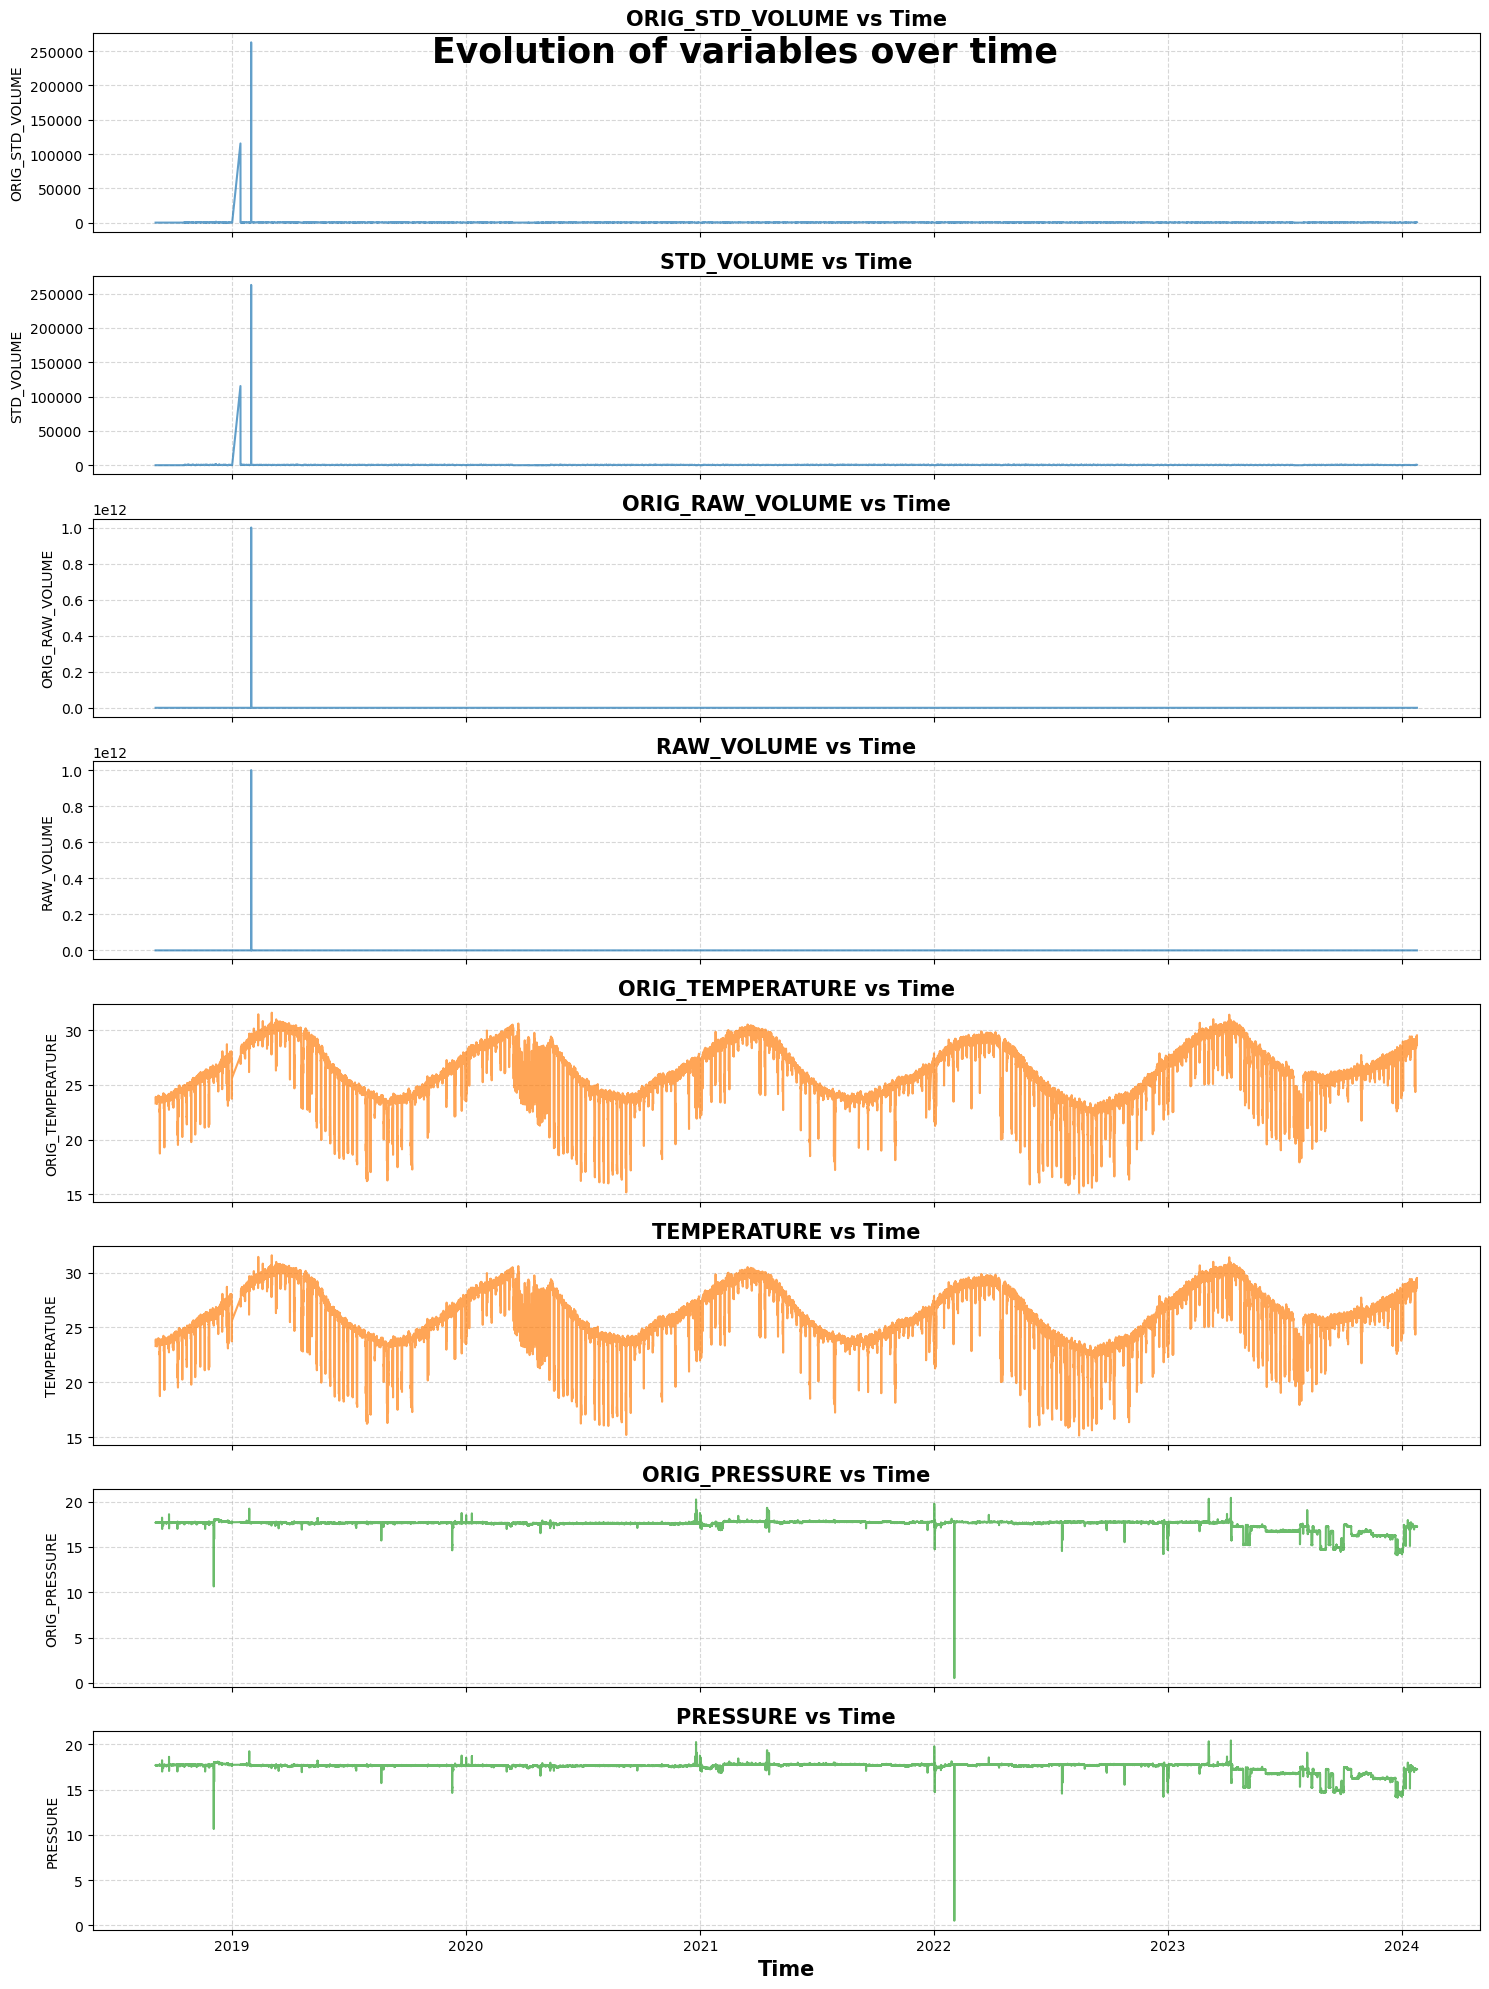

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convertir la columna EFFECTIVE_DATE a datetime si no lo está
e1['EFFECTIVE_DATE'] = pd.to_datetime(e1['EFFECTIVE_DATE'])

# Definir las variables por categorías
volumen_vars = ['ORIG_STD_VOLUME', 'STD_VOLUME', 'ORIG_RAW_VOLUME', 'RAW_VOLUME']
temperatura_vars = ['ORIG_TEMPERATURE', 'TEMPERATURE']
presion_vars = ['ORIG_PRESSURE', 'PRESSURE']

# Unificar todas las variables en una sola lista para iteración
variables = volumen_vars + temperatura_vars + presion_vars

# Definir colores para cada categoría
colores = {
    'Volumen': '#1f77b4',      # Azul
    'Temperatura': '#ff7f0e',  # Naranja
    'Presión': '#2ca02c'       # Verde
}

# Crear una figura con subgráficos
fig, axs = plt.subplots(len(variables), 1, figsize=(15, 20), sharex=True)

# Iterar sobre las variables y asignar color según su categoría
for i, var in enumerate(variables):
    if var in volumen_vars:
        color = colores['Volumen']
    elif var in temperatura_vars:
        color = colores['Temperatura']
    else:
        color = colores['Presión']
    
    sns.lineplot(data=e1, x='EFFECTIVE_DATE', y=var, ax=axs[i], color=color, alpha=0.7)
    
    axs[i].set_title(f'{var} vs Time', fontsize=15, fontweight='bold')
    axs[i].set_ylabel(var)
    axs[i].grid(True, linestyle='--', alpha=0.5)  # Agregar grid ligero para mejor legibilidad

# Ajustar el diseño y la etiqueta del eje X
axs[-1].set_xlabel('Time', fontsize=15, fontweight='bold')

# Espaciado óptimo entre subgráficos
plt.tight_layout()

# Título general de la figura
plt.suptitle("Evolution of variables over time", fontsize=25, fontweight='bold')
plt.show()


/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: F

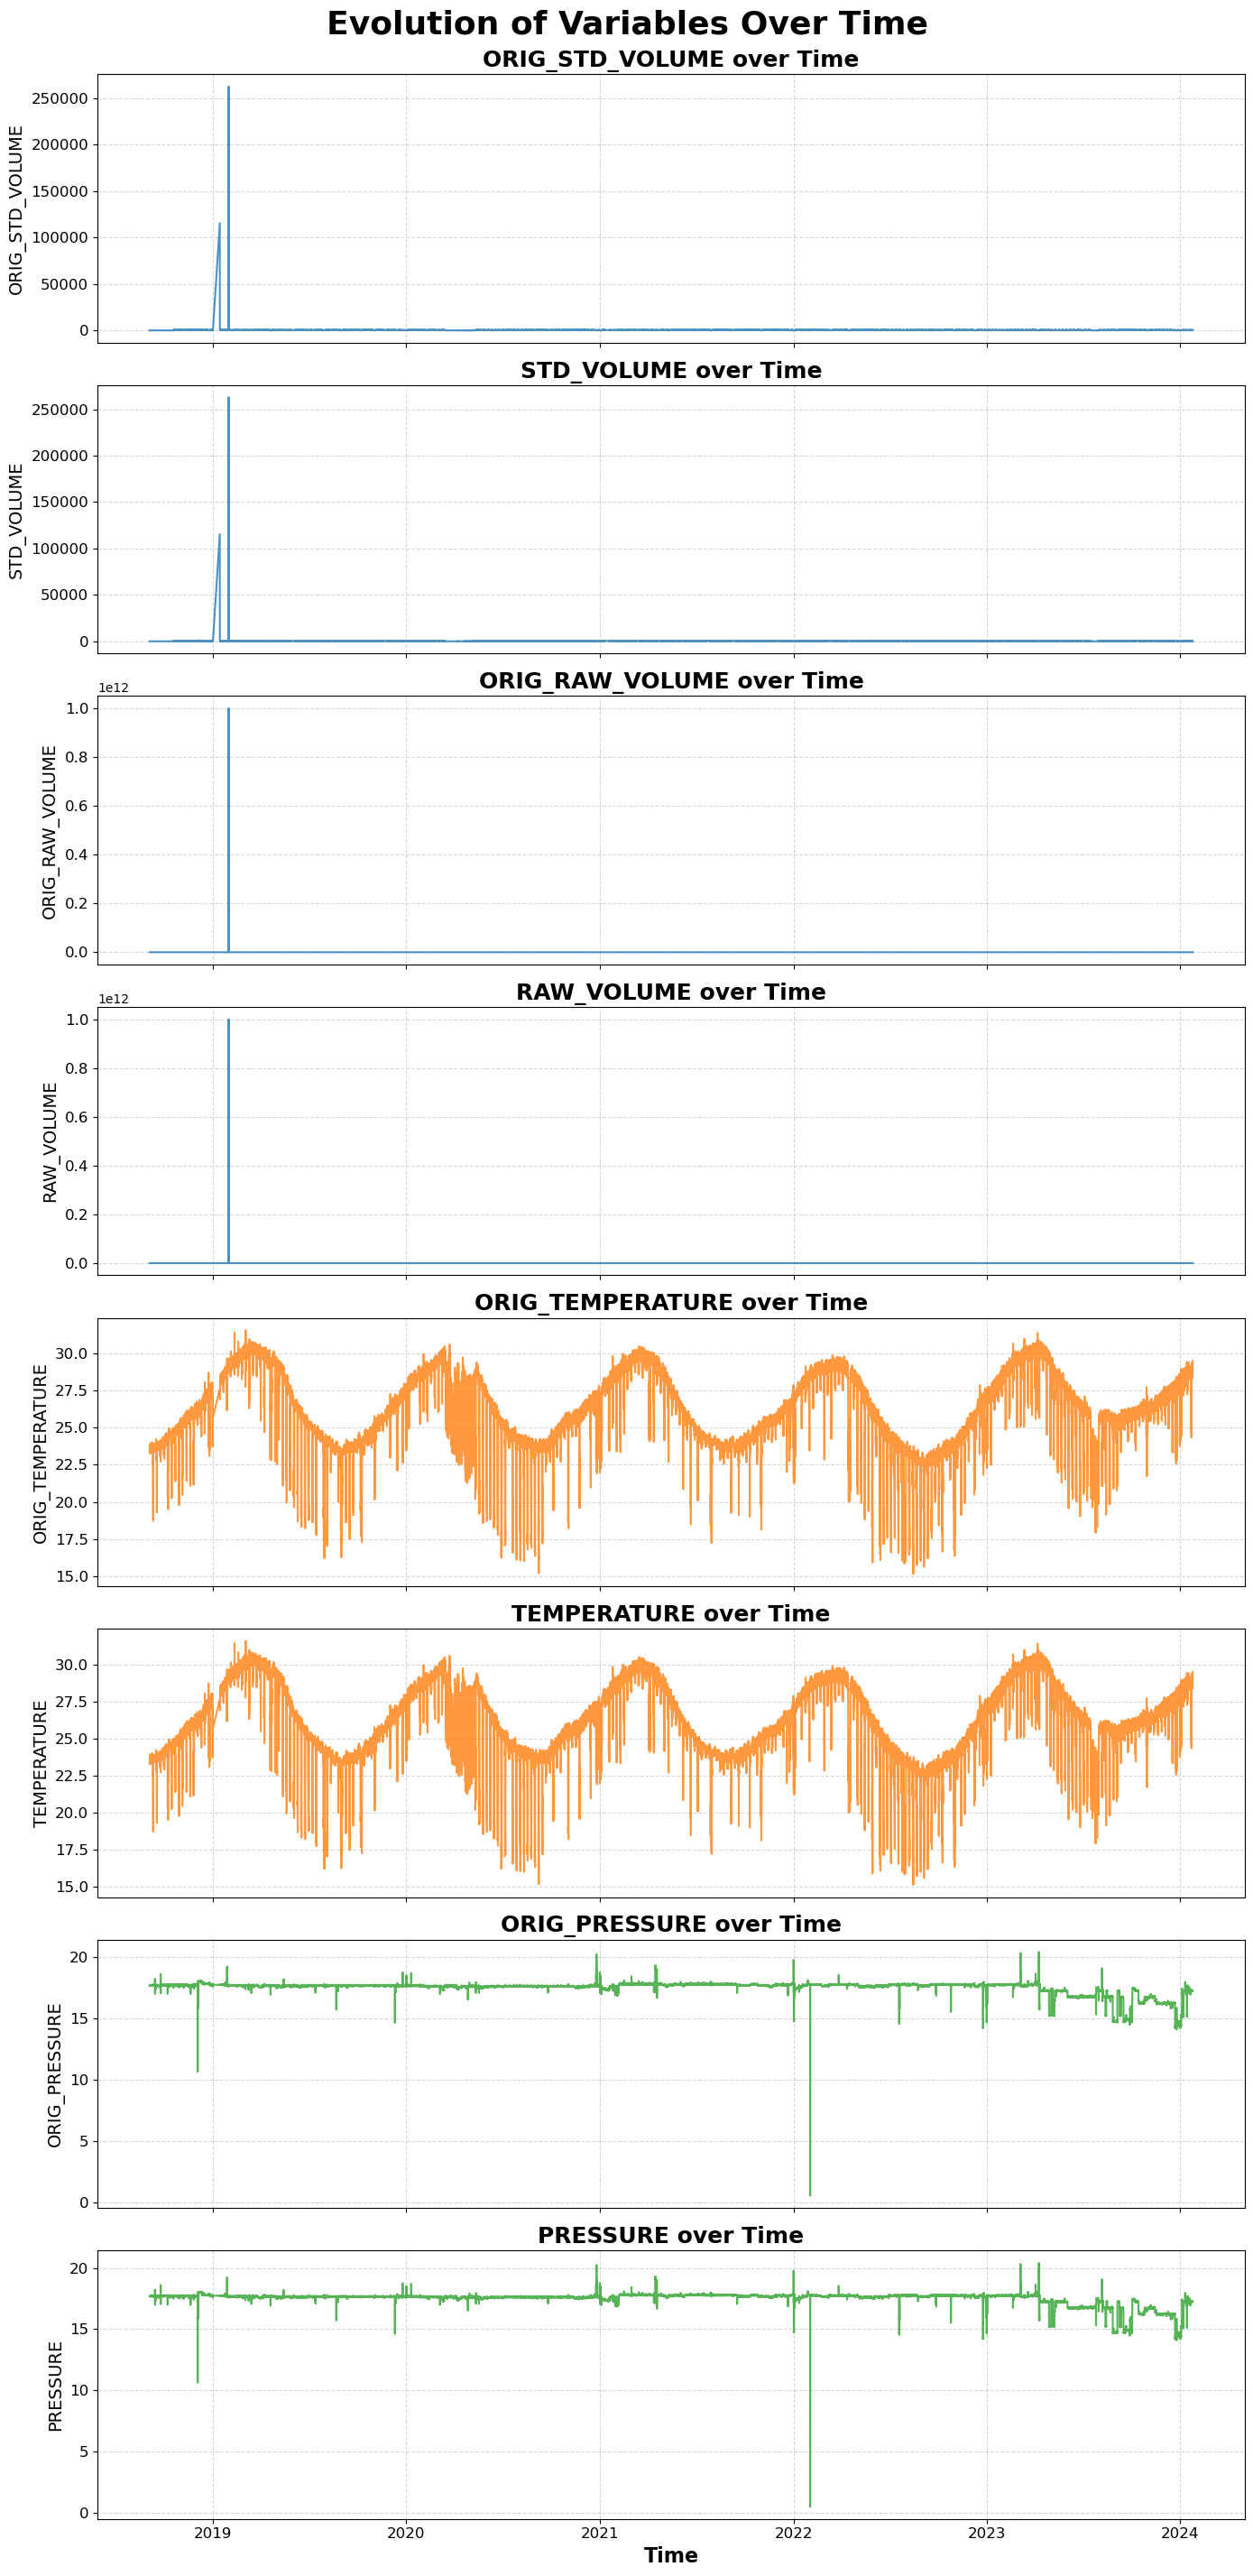

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert EFFECTIVE_DATE to datetime if not already
e1['EFFECTIVE_DATE'] = pd.to_datetime(e1['EFFECTIVE_DATE'])

# Define variable categories
volume_vars = ['ORIG_STD_VOLUME', 'STD_VOLUME', 'ORIG_RAW_VOLUME', 'RAW_VOLUME']
temperature_vars = ['ORIG_TEMPERATURE', 'TEMPERATURE']
pressure_vars = ['ORIG_PRESSURE', 'PRESSURE']

# Combine all variables into a single list
variables = volume_vars + temperature_vars + pressure_vars

# Define colors by category
colors = {
    'Volume': '#1f77b4',       # Blue
    'Temperature': '#ff7f0e',  # Orange
    'Pressure': '#2ca02c'      # Green
}

# Create vertically long figure
fig, axs = plt.subplots(len(variables), 1, figsize=(14, 30), sharex=True)

# Plot each variable
for i, var in enumerate(variables):
    if var in volume_vars:
        color = colors['Volume']
    elif var in temperature_vars:
        color = colors['Temperature']
    else:
        color = colors['Pressure']
    
    sns.lineplot(data=e1, x='EFFECTIVE_DATE', y=var, ax=axs[i], color=color, alpha=0.8)
    
    axs[i].set_title(f'{var} over Time', fontsize=18, fontweight='bold')
    axs[i].set_ylabel(var, fontsize=14)
    axs[i].tick_params(axis='y', labelsize=12)
    axs[i].grid(True, linestyle='--', alpha=0.5)

# Set common X-axis label
axs[-1].set_xlabel('Time', fontsize=16, fontweight='bold')
axs[-1].tick_params(axis='x', labelsize=12)

# Adjust layout and set overall title
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.suptitle("Evolution of Variables Over Time", fontsize=26, fontweight='bold')
plt.show()

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


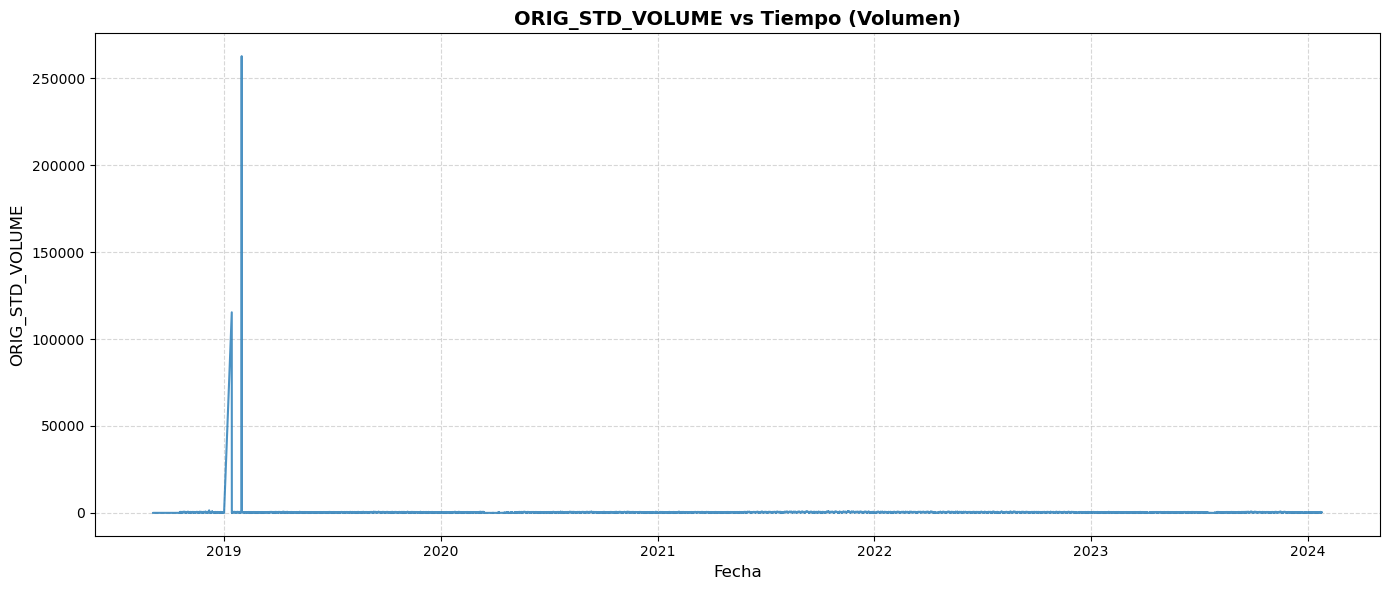

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


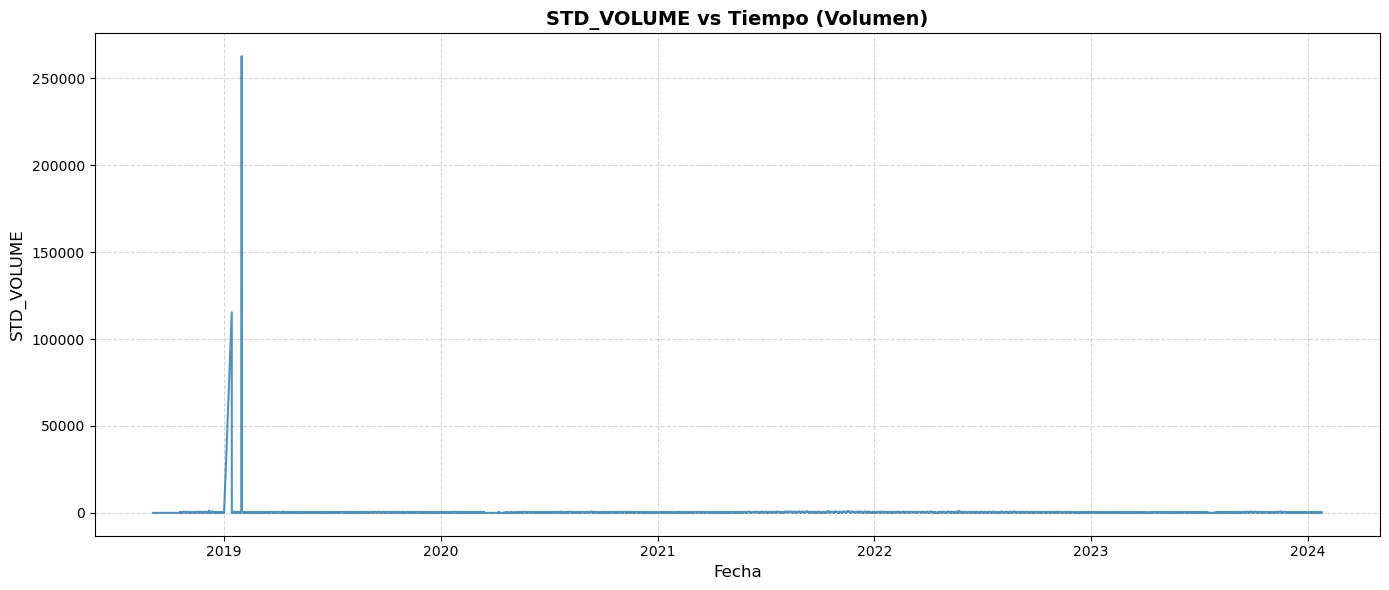

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


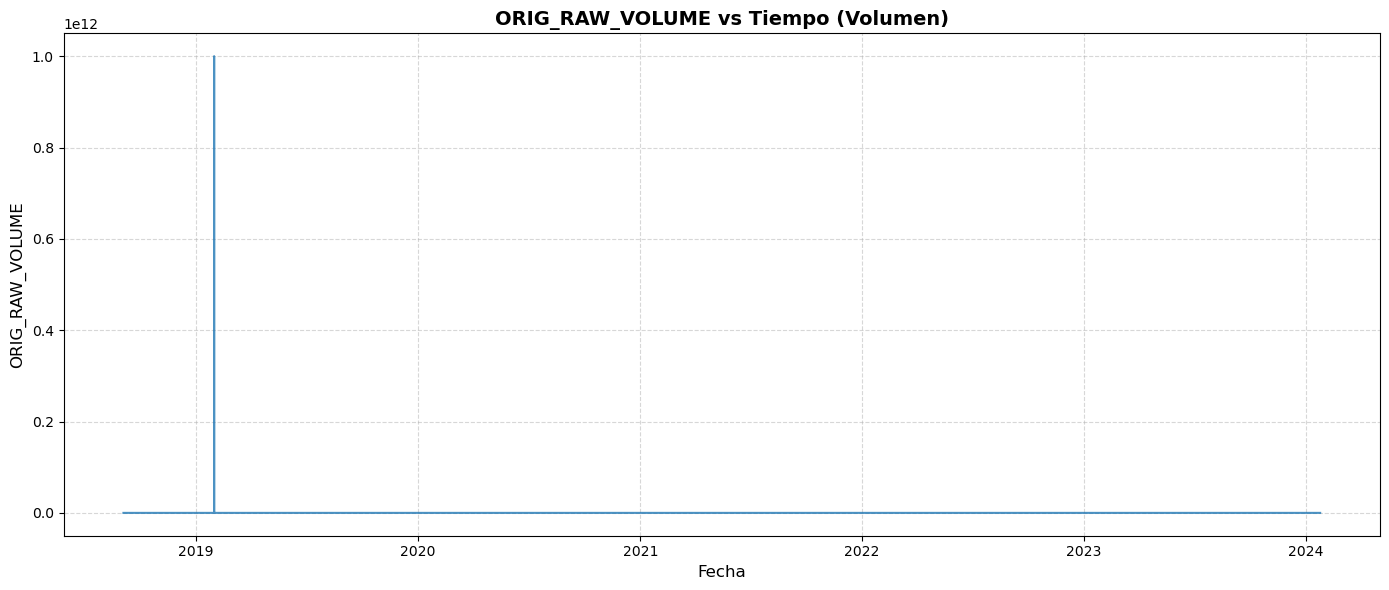

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


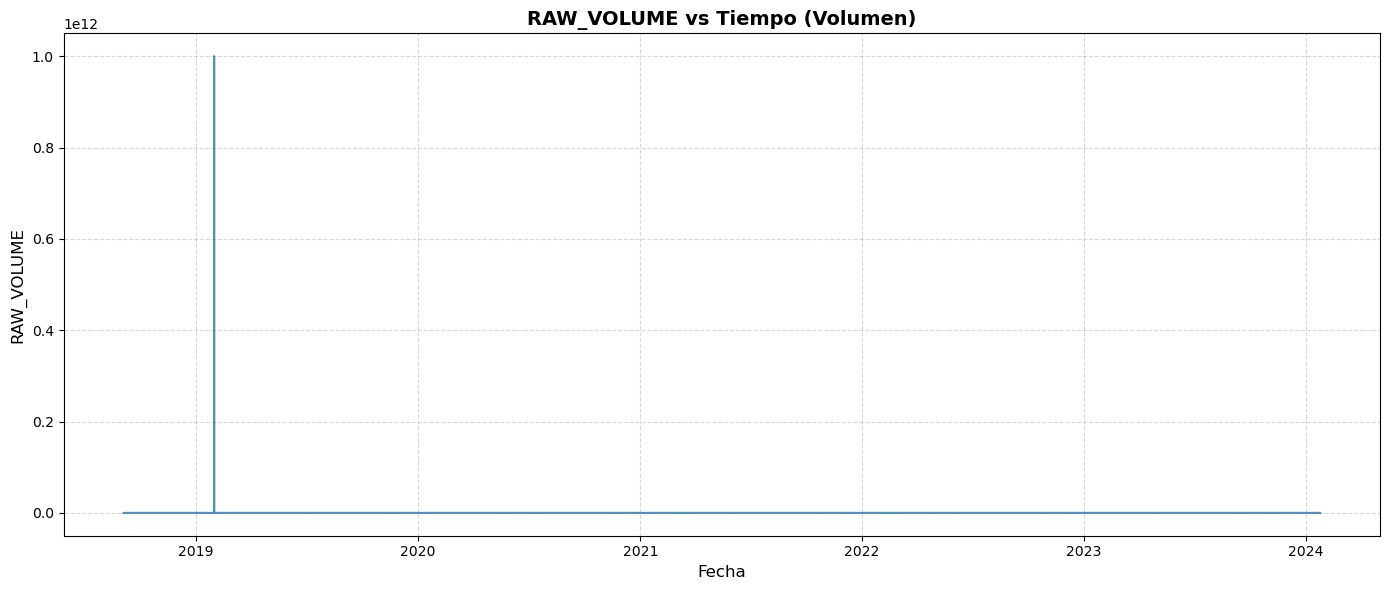

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


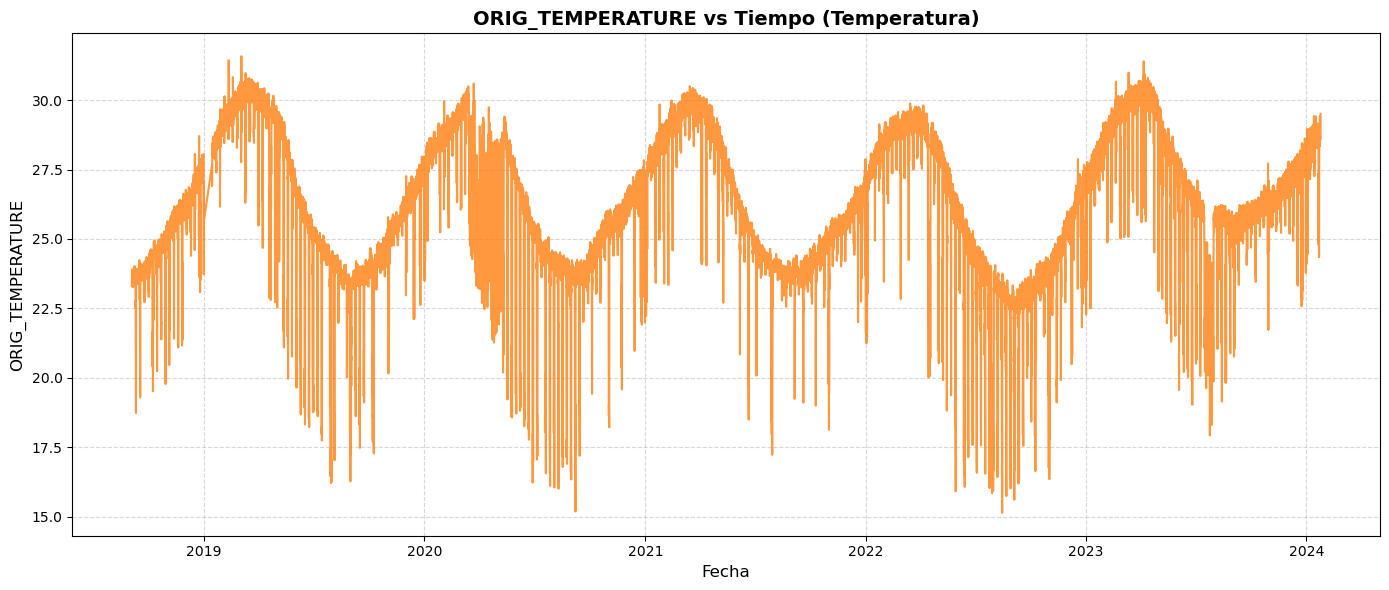

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


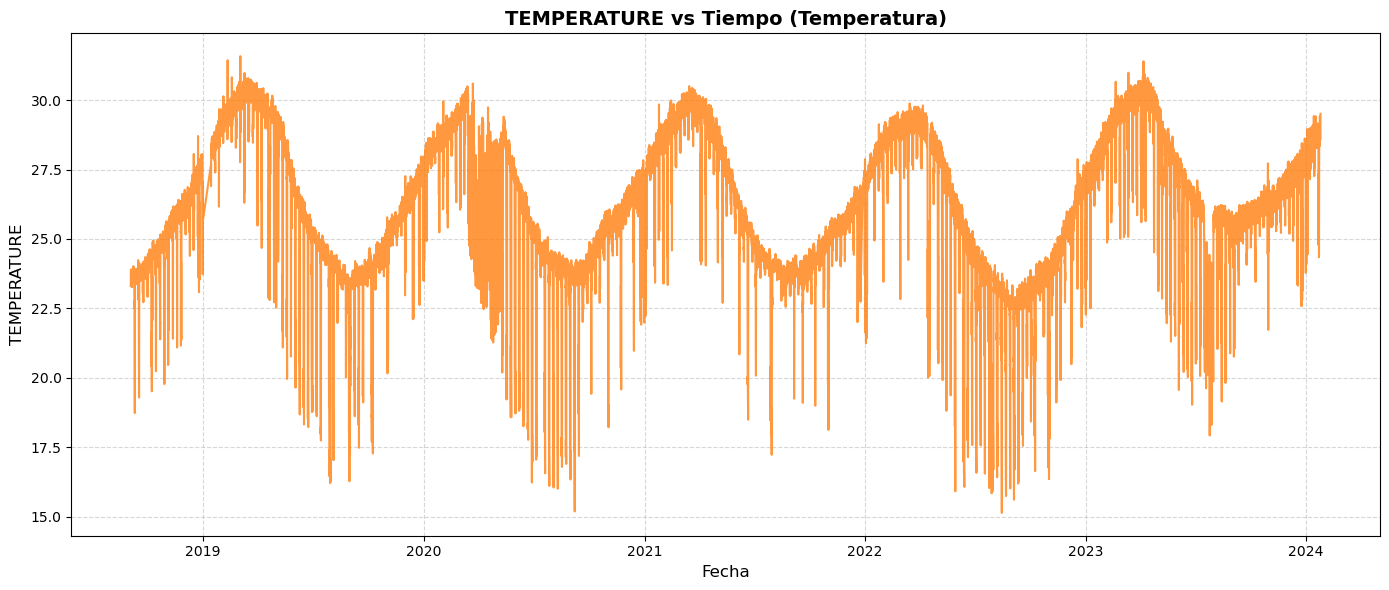

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


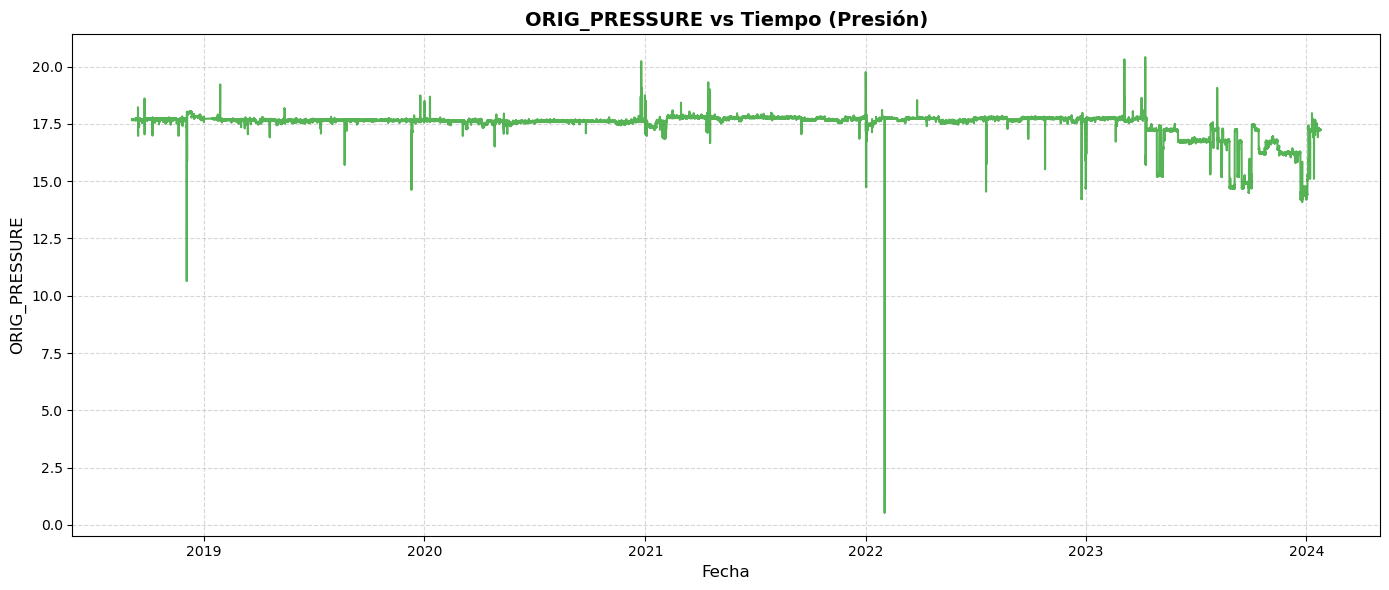

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


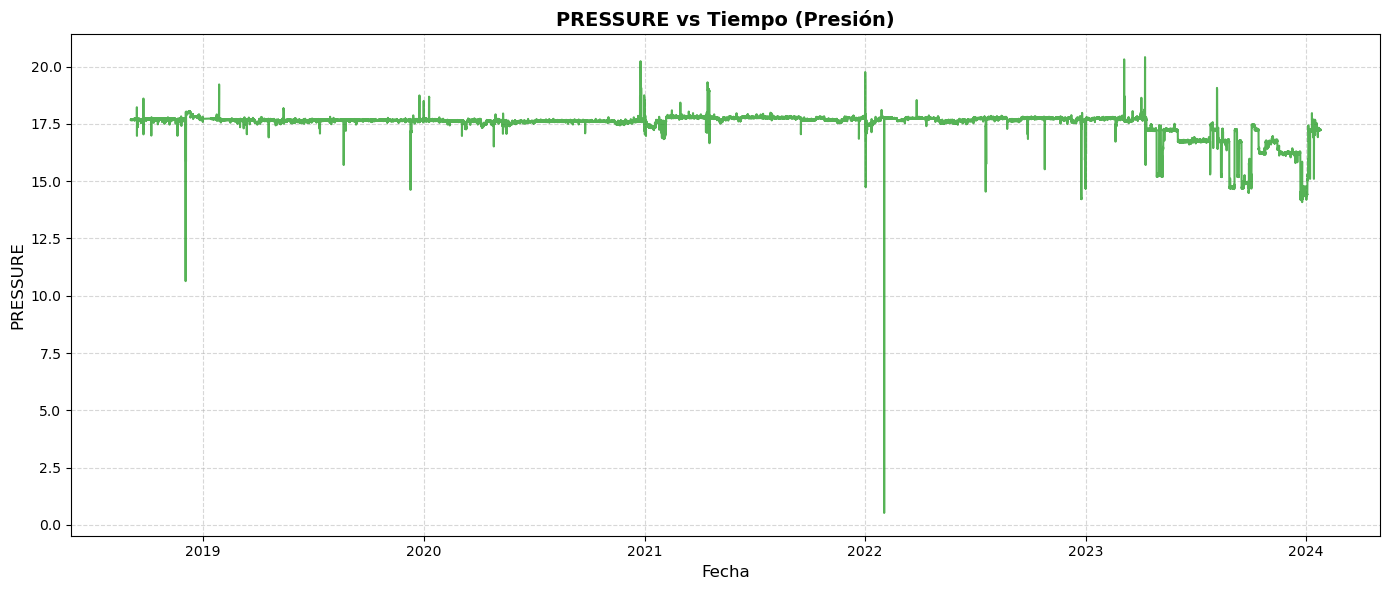

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurar que la columna de fecha esté en formato datetime
e1['EFFECTIVE_DATE'] = pd.to_datetime(e1['EFFECTIVE_DATE'])

# Definir las variables por categorías
volumen_vars = ['ORIG_STD_VOLUME', 'STD_VOLUME', 'ORIG_RAW_VOLUME', 'RAW_VOLUME']
temperatura_vars = ['ORIG_TEMPERATURE', 'TEMPERATURE']
presion_vars = ['ORIG_PRESSURE', 'PRESSURE']

# Asociar colores por categoría
colores = {
    'Volumen': '#1f77b4',      # Azul
    'Temperatura': '#ff7f0e',  # Naranja
    'Presión': '#2ca02c'       # Verde
}

# Función para obtener la categoría de una variable
def obtener_categoria(var):
    if var in volumen_vars:
        return 'Volumen'
    elif var in temperatura_vars:
        return 'Temperatura'
    else:
        return 'Presión'

# Lista con todas las variables
todas_las_vars = volumen_vars + temperatura_vars + presion_vars

# Mostrar una gráfica por variable
for var in todas_las_vars:
    categoria = obtener_categoria(var)
    color = colores[categoria]

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=e1, x='EFFECTIVE_DATE', y=var, color=color, alpha=0.8)

    plt.title(f'{var} vs Tiempo ({categoria})', fontsize=14, fontweight='bold')
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel(var, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    plt.show()

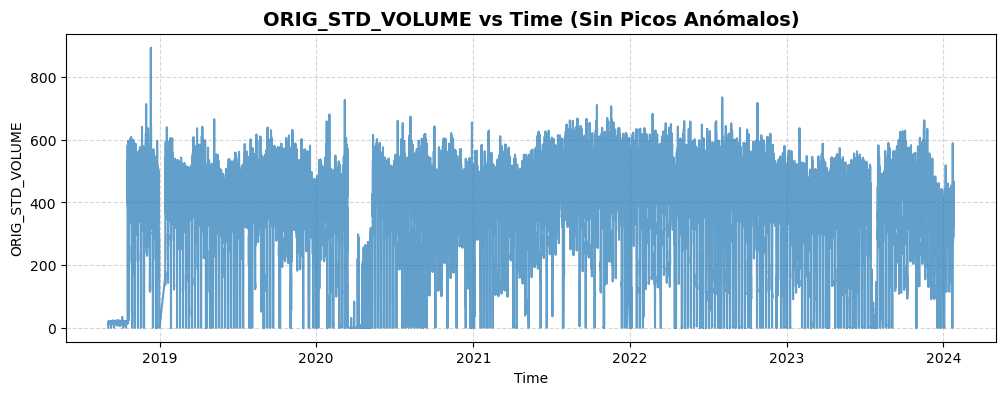

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Asumimos que ya tenemos los datos en un DataFrame llamado e1
# Primero, identificamos los dos valores más altos en ORIG_STD_VOLUME
top_values = e1['ORIG_STD_VOLUME'].nlargest(3)

# Filtramos los datos eliminando estos dos picos
e1_filtered = e1[~e1['ORIG_STD_VOLUME'].isin(top_values)]

# Crear la gráfica sin los picos
plt.figure(figsize=(12, 4))
plt.plot(e1_filtered['EFFECTIVE_DATE'], e1_filtered['ORIG_STD_VOLUME'], color='#1f77b4', alpha=0.7)
plt.title("ORIG_STD_VOLUME vs Time (Sin Picos Anómalos)", fontsize=14, fontweight='bold')
plt.xlabel("Time")
plt.ylabel("ORIG_STD_VOLUME")
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrar la gráfica
plt.show()


- El 1400 podría también anomalía

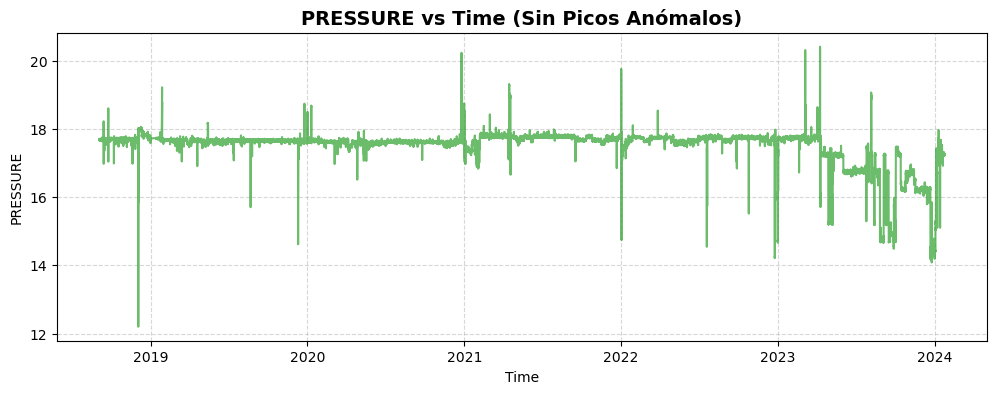

In [19]:
# Identificar los dos valores más altos en PRESSURE
top_values_pressure = e1['PRESSURE'].nlargest(2)
smallest_values_pressure = e1['PRESSURE'].nsmallest(3)

# Filtrar los datos eliminando estos dos picos
#e1_filtered_pressure = e1[~e1['PRESSURE'].isin(top_values_pressure)]
e1_filtered_pressure = e1[~e1['PRESSURE'].isin(smallest_values_pressure)]

# Crear la gráfica sin los picos en presión
plt.figure(figsize=(12, 4))
plt.plot(e1_filtered_pressure['EFFECTIVE_DATE'], e1_filtered_pressure['PRESSURE'], color='#2ca02c', alpha=0.7)
plt.title("PRESSURE vs Time (Sin Picos Anómalos)", fontsize=14, fontweight='bold')
plt.xlabel("Time")
plt.ylabel("PRESSURE")
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrar la gráfica
plt.show()


In [20]:
# Crear un nuevo DataFrame con los datos filtrados
e1_filtered_data = e1.copy()

# Eliminar los 3 valores más altos de ORIG_STD_VOLUME
top_values_volume = e1['ORIG_STD_VOLUME'].nlargest(3)
e1_filtered_data = e1_filtered_data[~e1_filtered_data['ORIG_STD_VOLUME'].isin(top_values_volume)]

# Eliminar los 3 valores más bajos de PRESSURE
smallest_values_pressure = e1['PRESSURE'].nsmallest(3)
e1_filtered_data = e1_filtered_data[~e1_filtered_data['PRESSURE'].isin(smallest_values_pressure)]



/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


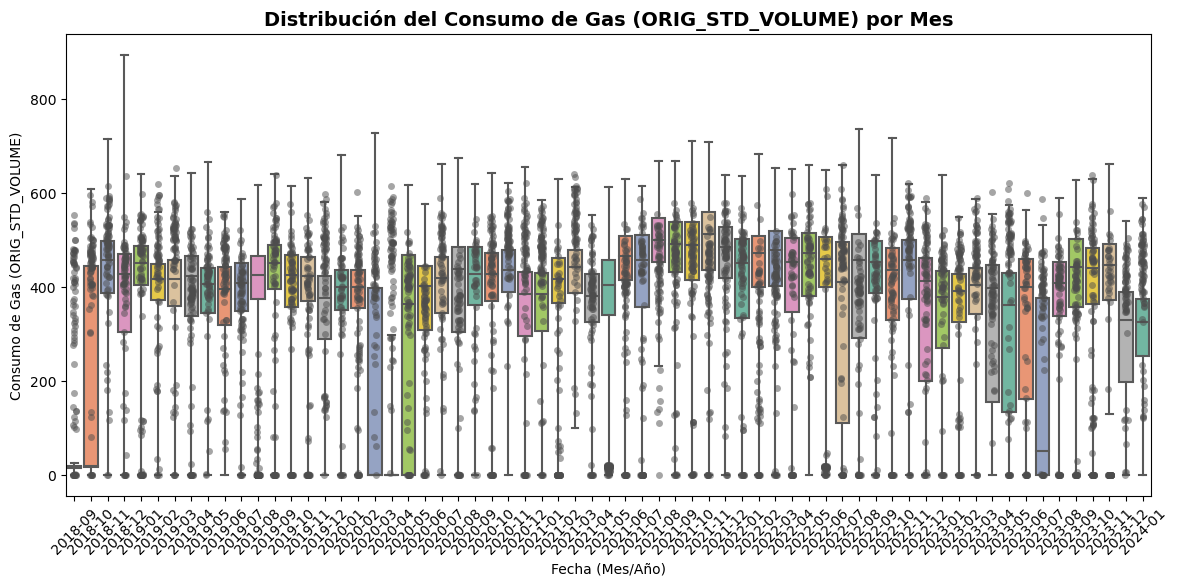

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Crear una copia del DataFrame procesado
processed_e1_df = e1_filtered_data.copy()

# Convertir la fecha a un formato de periodo mensual para mejor agrupación
processed_e1_df['YearMonth'] = processed_e1_df['EFFECTIVE_DATE'].dt.to_period("M")

# Configurar la figura
plt.figure(figsize=(14, 6))

# Crear el boxplot para el consumo de gas
ax = sns.boxplot(
    data=processed_e1_df,
    x='YearMonth',
    y='ORIG_STD_VOLUME',  # También puedes probar con ORIG_STD_VOLUME
    palette='Set2',
    whis=np.inf  # Incluir todos los valores sin limitar los bigotes
)

# Añadir el stripplot para visualizar los valores individuales
ax = sns.stripplot(
    data=processed_e1_df.sample(frac=0.1, random_state=42),  # Muestrear para evitar sobrecarga
    x='YearMonth',
    y='ORIG_STD_VOLUME',
    color='.3',
    alpha=0.5
)

# Configurar el título y etiquetas
plt.title('Distribución del Consumo de Gas (ORIG_STD_VOLUME) por Mes', fontsize=14, fontweight='bold')
plt.xlabel('Fecha (Mes/Año)')
plt.ylabel('Consumo de Gas (ORIG_STD_VOLUME)')

# Rotar etiquetas del eje X para mejorar visibilidad
plt.xticks(rotation=45)

# Mostrar la gráfica
plt.show()


/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


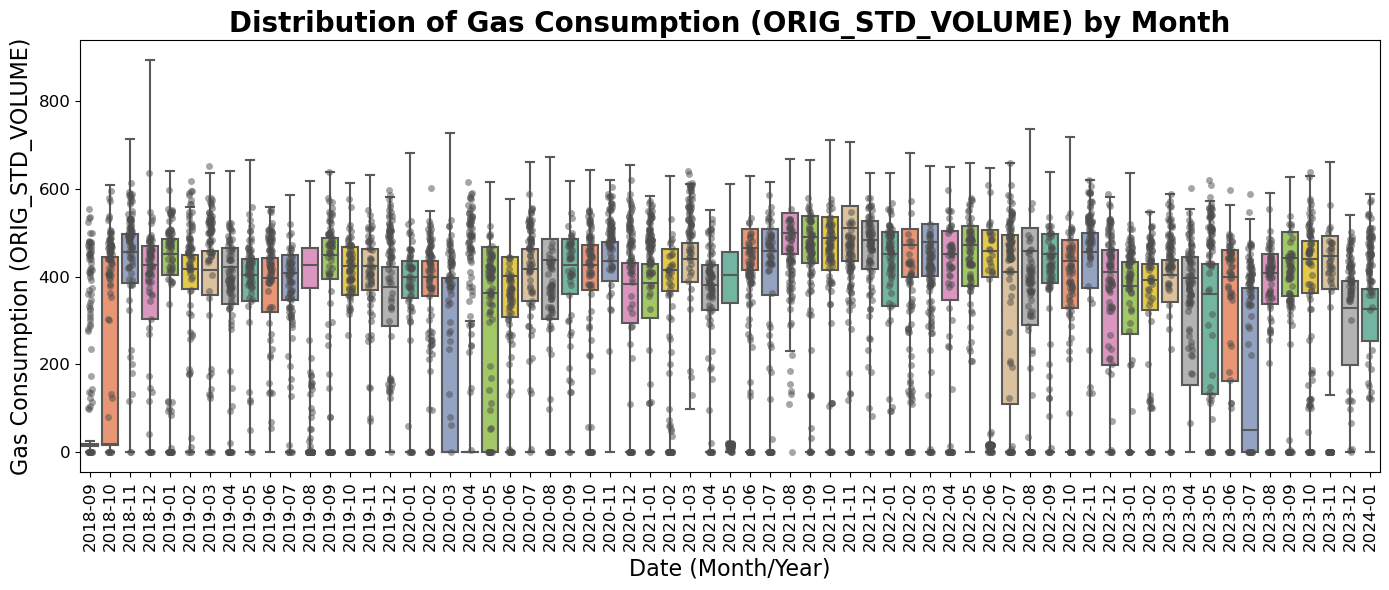

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a copy of the processed DataFrame
processed_e1_df = e1_filtered_data.copy()

# Convert the date to a Year-Month period for better grouping
processed_e1_df['YearMonth'] = processed_e1_df['EFFECTIVE_DATE'].dt.to_period("M")

# Configurar la figura
plt.figure(figsize=(14, 6))

# Create the boxplot for gas consumption
ax = sns.boxplot(
    data=processed_e1_df,
    x='YearMonth',
    y='ORIG_STD_VOLUME',
    palette='Set2',
    whis=np.inf  # Include all values (no whisker limits)
)

# Add a stripplot to show individual values
ax = sns.stripplot(
    data=processed_e1_df.sample(frac=0.1, random_state=42),  # Sample to avoid overplotting
    x='YearMonth',
    y='ORIG_STD_VOLUME',
    color='.3',
    alpha=0.5
)

# Set title and axis labels in English
plt.title('Distribution of Gas Consumption (ORIG_STD_VOLUME) by Month', fontsize=20, fontweight='bold')
plt.xlabel('Date (Month/Year)', fontsize=16)
plt.ylabel('Gas Consumption (ORIG_STD_VOLUME)', fontsize=16)

# Rotate X-axis tick labels vertically
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


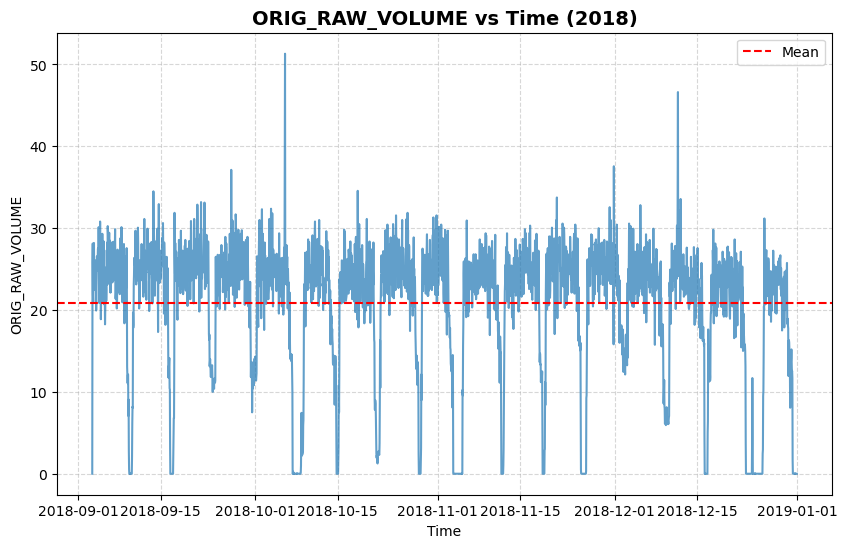

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


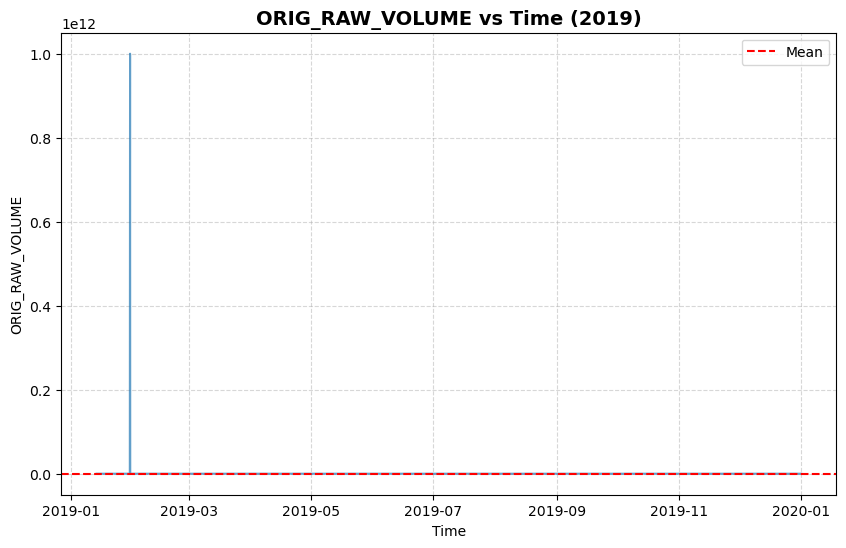

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


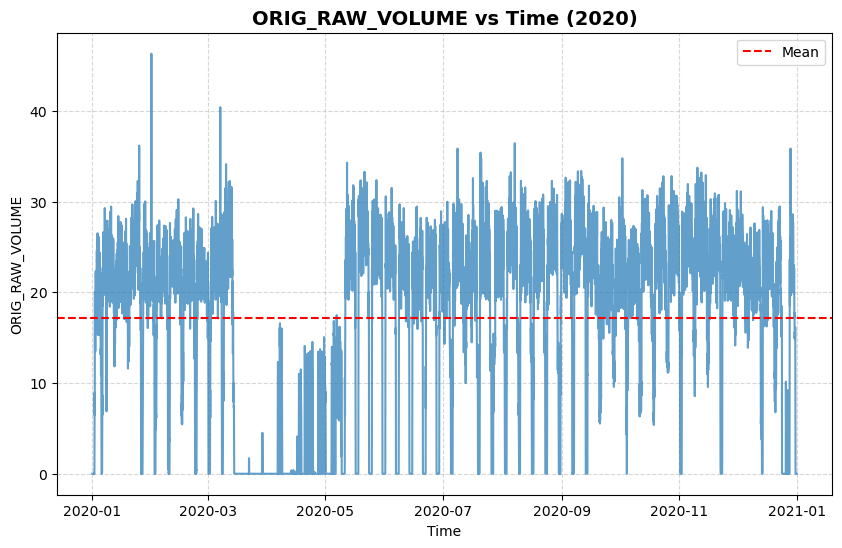

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


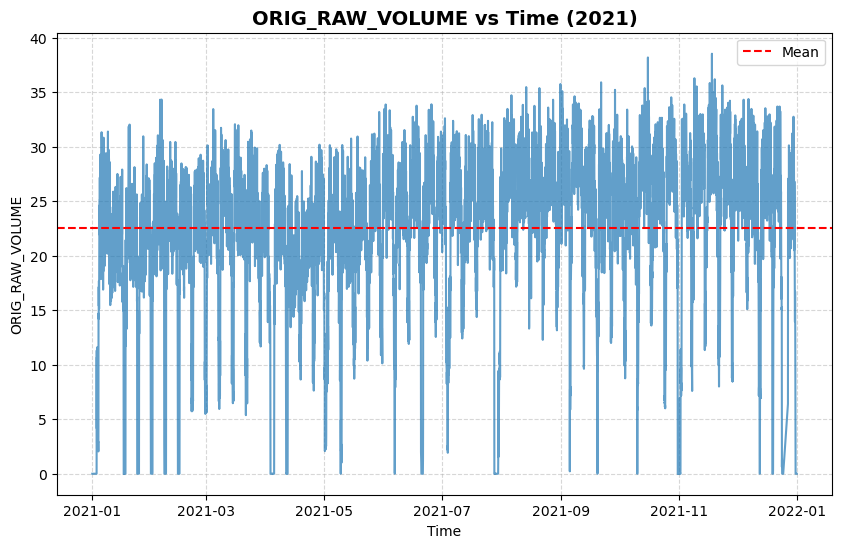

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


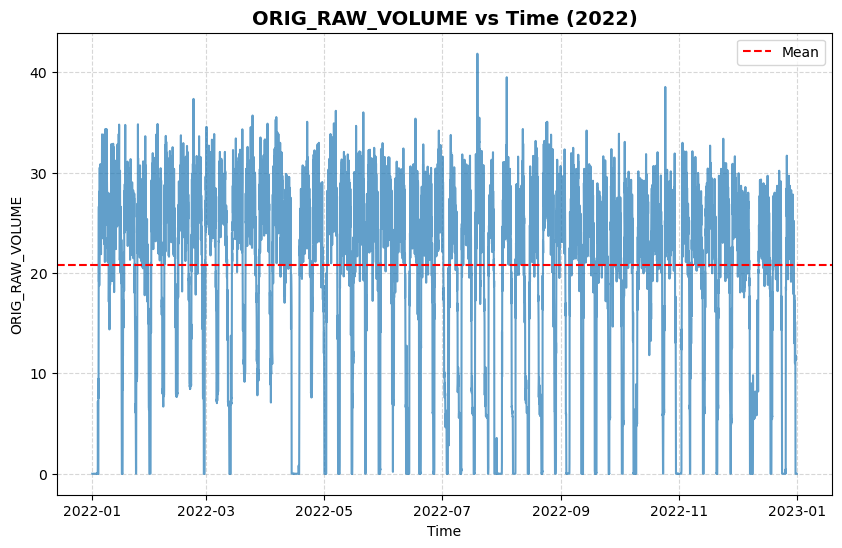

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


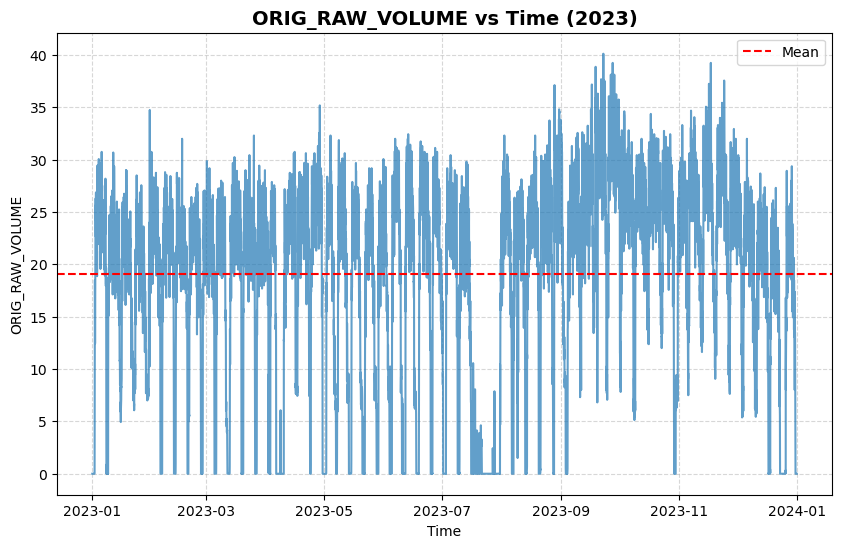

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


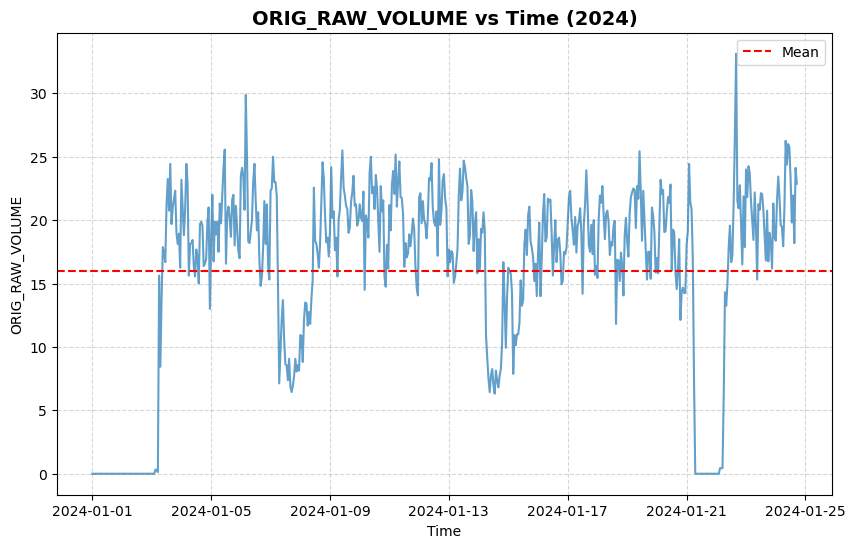

In [23]:
# Filtrar los datos por año y crear una gráfica para cada año
years = e1_filtered_data['EFFECTIVE_DATE'].dt.year.unique()
volumen_vars = ['ORIG_RAW_VOLUME']

for year in years:
    yearly_data = e1_filtered_data[e1_filtered_data['EFFECTIVE_DATE'].dt.year == year]
    
    for var in volumen_vars:
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=yearly_data, x='EFFECTIVE_DATE', y=var, color=colores['Volumen'], alpha=0.7)
        
        plt.title(f'{var} vs Time ({year})', fontsize=14, fontweight='bold')
        plt.xlabel('Time')
        plt.ylabel(var)
        plt.grid(True, linestyle='--', alpha=0.5)
        
        # Principios de Gestalt: Proximidad y Similitud
        plt.axhline(y=yearly_data[var].mean(), color='red', linestyle='--', label='Mean')
        plt.legend()
        
        plt.show()

## Conclusiones



In [25]:
e1 = pd.read_excel(r"/Users/alejandrabenavidessanclemente/Downloads/EICH101.xlsx")

In [26]:
# Filtrar los datos eliminando los valores que superen 60 en ORIG_RAW_VOLUME
e1_filtered = e1[e1['ORIG_RAW_VOLUME'] <= 60]


In [27]:
e1_filtered.loc[:, 'EFFECTIVE_DATE'] = pd.to_datetime(e1_filtered['EFFECTIVE_DATE'])

/var/folders/kx/dbhh3d1110gd9sx_9wy22n1m0000gn/T/ipykernel_3071/292461213.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  e1_filtered['EFFECTIVE_DATE'] = pd.to_datetime(e1_filtered['EFFECTIVE_DATE'])
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with p

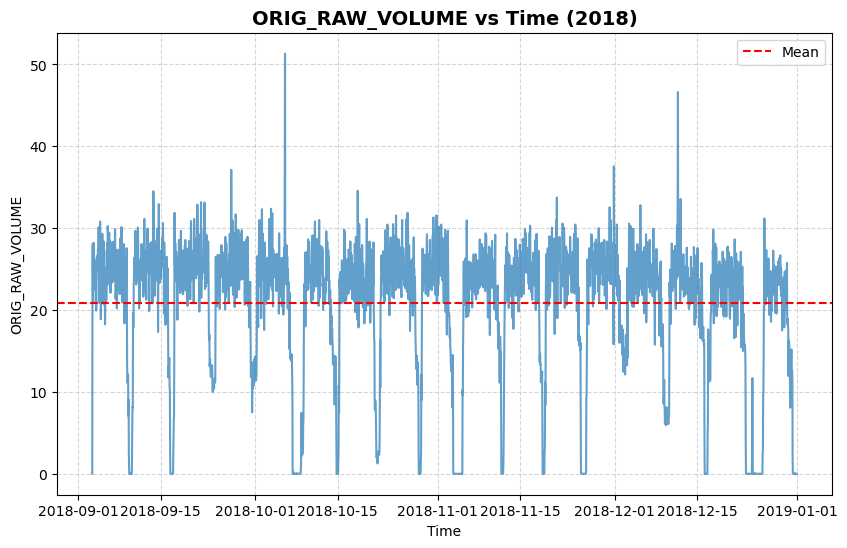

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


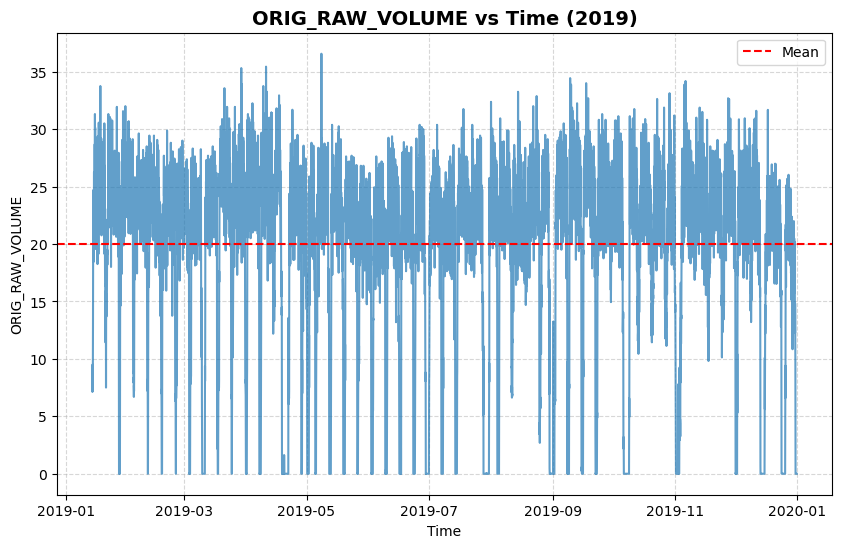

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


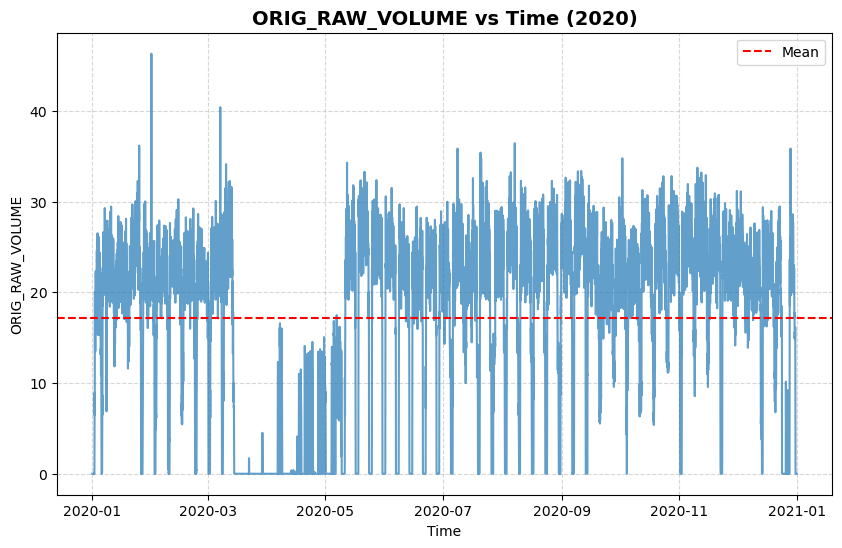

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


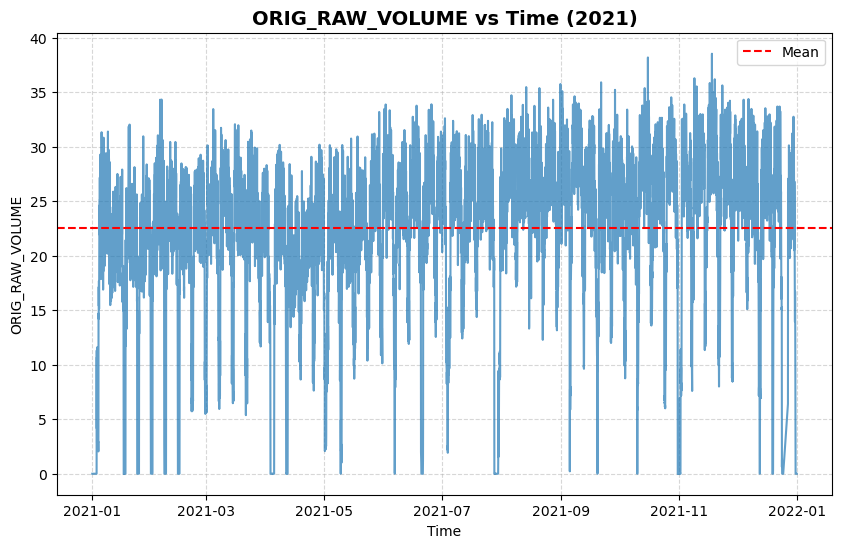

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


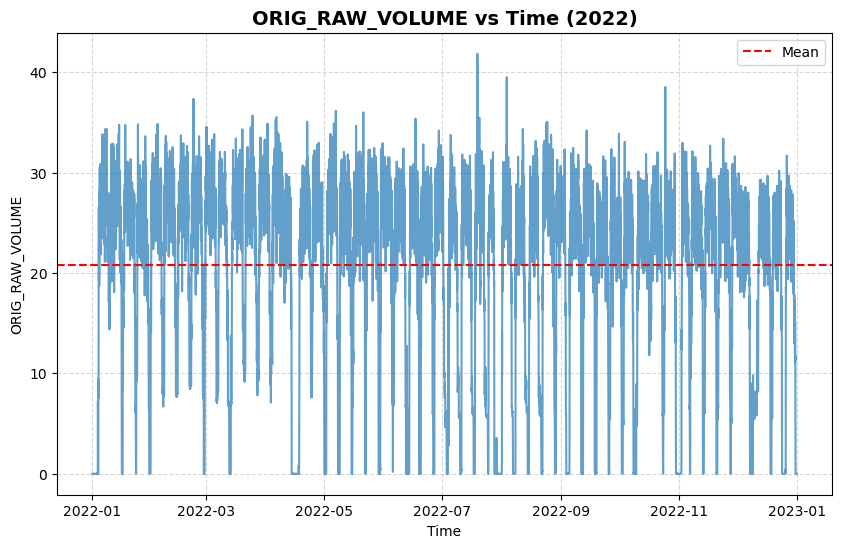

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


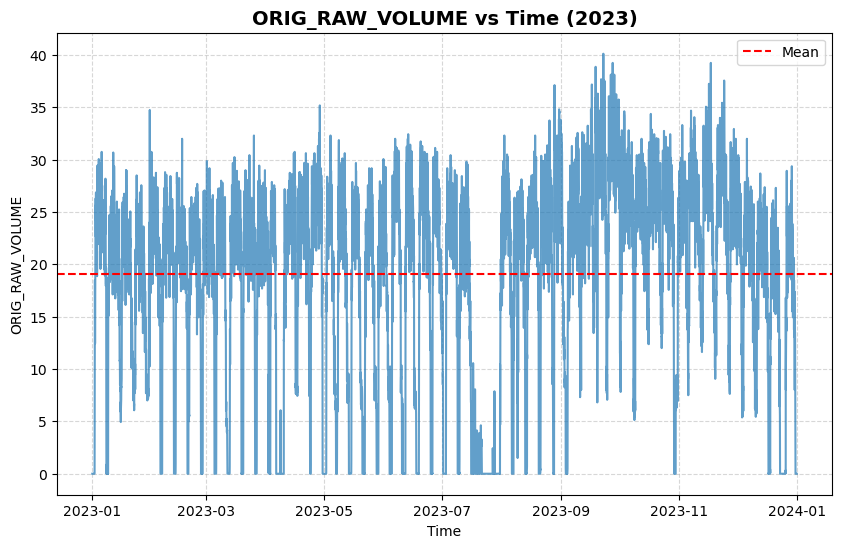

/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/alejandrabenavidessanclemente/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


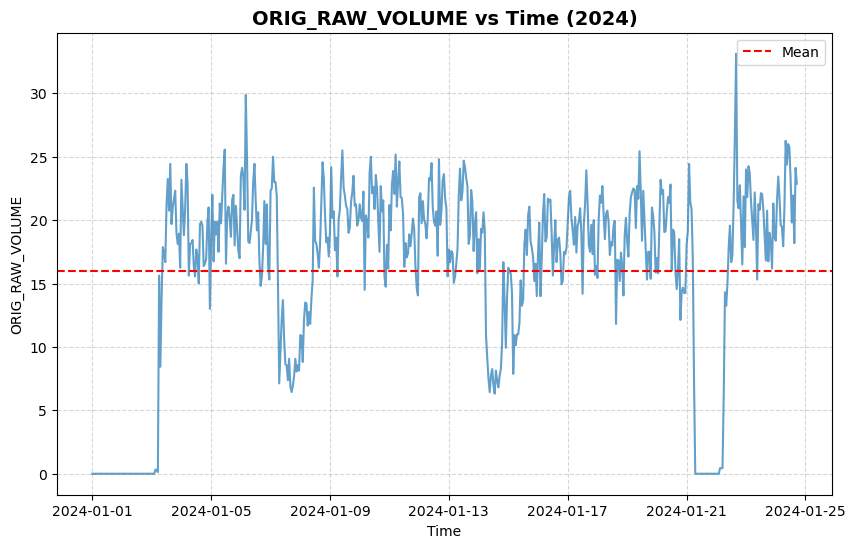

In [28]:
# Asegurarse de que la columna EFFECTIVE_DATE es de tipo datetime
e1_filtered['EFFECTIVE_DATE'] = pd.to_datetime(e1_filtered['EFFECTIVE_DATE'])

# Filtrar los datos por año y crear una gráfica para cada año
years = e1_filtered['EFFECTIVE_DATE'].dt.year.unique()
volumen_vars = ['ORIG_RAW_VOLUME']

for year in years:
    yearly_data = e1_filtered[e1_filtered['EFFECTIVE_DATE'].dt.year == year]
    
    for var in volumen_vars:
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=yearly_data, x='EFFECTIVE_DATE', y=var, color=colores['Volumen'], alpha=0.7)
        
        plt.title(f'{var} vs Time ({year})', fontsize=14, fontweight='bold')
        plt.xlabel('Time')
        plt.ylabel(var)
        plt.grid(True, linestyle='--', alpha=0.5)
        
        # Principios de Gestalt: Proximidad y Similitud
        plt.axhline(y=yearly_data[var].mean(), color='red', linestyle='--', label='Mean')
        plt.legend()
        
        plt.show()

In [ ]:
import pywt
import numpy as np

import matplotlib.pyplot as plt

# Obtener los años únicos en e1_filtered
years = e1_filtered['EFFECTIVE_DATE'].dt.year.unique()

# Iterar sobre cada año
for year in years:
    # Filtrar los datos para el año actual
    yearly_data = e1_filtered[e1_filtered['EFFECTIVE_DATE'].dt.year == year]
    
    # Extraer los valores de ORIG_RAW_VOLUME para el año actual
    signal = yearly_data['ORIG_RAW_VOLUME'].dropna().values
    
    # Aplicar la Transformada Wavelet Discreta (DWT) usando la wavelet 'db4'
    coeffs = pywt.wavedec(signal, wavelet='db4', level=5)
    
    # Reconstrucción de la señal a partir de los coeficientes
    reconstructed_signal = pywt.waverec(coeffs, wavelet='db4')
    
    # Ajustar la longitud de la señal reconstruida para coincidir con la original
    reconstructed_signal = reconstructed_signal[:len(signal)]
    
    # Graficar la señal original y la reconstruida
    plt.figure(figsize=(12, 6))
    plt.plot(yearly_data['EFFECTIVE_DATE'][:len(signal)], signal, label='Señal Original', color='blue', alpha=0.6)
    plt.plot(yearly_data['EFFECTIVE_DATE'][:len(signal)], reconstructed_signal, label='Señal Reconstruida (Wavelet)', color='red', linestyle='dashed', alpha=0.7)
    plt.xlabel('Fecha')
    plt.ylabel('Consumo de Gas (ORIG_RAW_VOLUME)')
    plt.title(f'Transformada Wavelet en Consumo de Gas ({year})', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)  # Rotar etiquetas del eje X para mejor visibilidad
    plt.show()

In [ ]:
# Obtener los años únicos en e1_filtered
years = e1_filtered['EFFECTIVE_DATE'].dt.year.unique()

# Definir escalas para la transformada
scales = np.arange(1, 128)

# Iterar sobre cada año
for year in years:
    # Filtrar los datos para el año actual
    yearly_data = e1_filtered[e1_filtered['EFFECTIVE_DATE'].dt.year == year]
    
    # Extraer los valores de ORIG_RAW_VOLUME para el año actual
    signal = yearly_data['ORIG_RAW_VOLUME'].dropna().values
    
    # Aplicar la Transformada Wavelet Continua (CWT) usando la wavelet Morlet
    coefficients, frequencies = pywt.cwt(signal, scales, 'morl')
    
    # Graficar el escalograma correctamente con imshow
    plt.figure(figsize=(12, 6))
    plt.imshow(np.abs(coefficients), aspect='auto', cmap='jet', extent=[yearly_data['EFFECTIVE_DATE'].min(), yearly_data['EFFECTIVE_DATE'].max(), scales[-1], scales[0]])
    plt.colorbar(label="Magnitud de los Coeficientes")
    plt.xlabel("Fecha")
    plt.ylabel("Escala")
    plt.title(f"Escalograma de Consumo de Gas (Wavelet CWT - {year})", fontsize=14, fontweight="bold")
    plt.show()

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
import os
import pandas as pd

# Asegurarse de que EFFECTIVE_DATE es datetime
e1_filtered['EFFECTIVE_DATE'] = pd.to_datetime(e1_filtered['EFFECTIVE_DATE'])

# Definir rango de fechas
start_date = pd.to_datetime("2023-12-10")
end_date = pd.to_datetime("2023-12-16")

# Crear carpeta de salida
output_folder = "graficas_diciembre"
os.makedirs(output_folder, exist_ok=True)

# Definir escalas para la transformada Wavelet
scales = np.arange(1, 128)

# Iterar por cada día dentro del rango
for current_date in pd.date_range(start=start_date, end=end_date):
    next_day = current_date + pd.Timedelta(days=1)

    # Filtrar datos del día
    df_day = e1_filtered[(e1_filtered['EFFECTIVE_DATE'] >= current_date) &
                         (e1_filtered['EFFECTIVE_DATE'] < next_day)]

    if df_day.empty:
        print(f"No data for {current_date.date()}, skipping...")
        continue

    # Extraer la señal
    signal_day = df_day['ORIG_RAW_VOLUME'].values

    # Aplicar la Transformada Wavelet Continua
    coefficients, frequencies = pywt.cwt(signal_day, scales, 'morl')

    # Crear la figura
    plt.figure(figsize=(18, 8))
    img =plt.imshow(np.abs(coefficients), aspect='auto', cmap='jet',
               extent=[0, len(signal_day), scales[-1], scales[0]])

    # Título y etiquetas en inglés
    date_str = current_date.strftime("%B %d, %Y")
    filename_date = current_date.strftime("%Y_%m_%d")
    plt.title(f"Wavelet Scalogram - {date_str}", fontsize=24, fontweight="bold")
    plt.xlabel("Time (Hour Index)", fontsize=18)
    plt.ylabel("Scale", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    # Add colorbar
    cbar = plt.colorbar(img)
    cbar.set_label("Magnitude", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    # Guardar la imagen
    filename = f"wavelet_scalogram_{filename_date}.png"
    filepath = os.path.join(output_folder, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Wavelet saved for {date_str} at: {filepath}")

/var/folders/kx/dbhh3d1110gd9sx_9wy22n1m0000gn/T/ipykernel_3071/1813828709.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  e1_filtered['EFFECTIVE_DATE'] = pd.to_datetime(e1_filtered['EFFECTIVE_DATE'])


Wavelet saved for December 10, 2023 at: graficas_diciembre/wavelet_scalogram_2023_12_10.png
Wavelet saved for December 11, 2023 at: graficas_diciembre/wavelet_scalogram_2023_12_11.png
Wavelet saved for December 12, 2023 at: graficas_diciembre/wavelet_scalogram_2023_12_12.png
Wavelet saved for December 13, 2023 at: graficas_diciembre/wavelet_scalogram_2023_12_13.png
Wavelet saved for December 14, 2023 at: graficas_diciembre/wavelet_scalogram_2023_12_14.png
Wavelet saved for December 15, 2023 at: graficas_diciembre/wavelet_scalogram_2023_12_15.png
Wavelet saved for December 16, 2023 at: graficas_diciembre/wavelet_scalogram_2023_12_16.png


/var/folders/kx/dbhh3d1110gd9sx_9wy22n1m0000gn/T/ipykernel_3071/329923280.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  e1_filtered['EFFECTIVE_DATE'] = pd.to_datetime(e1_filtered['EFFECTIVE_DATE'])


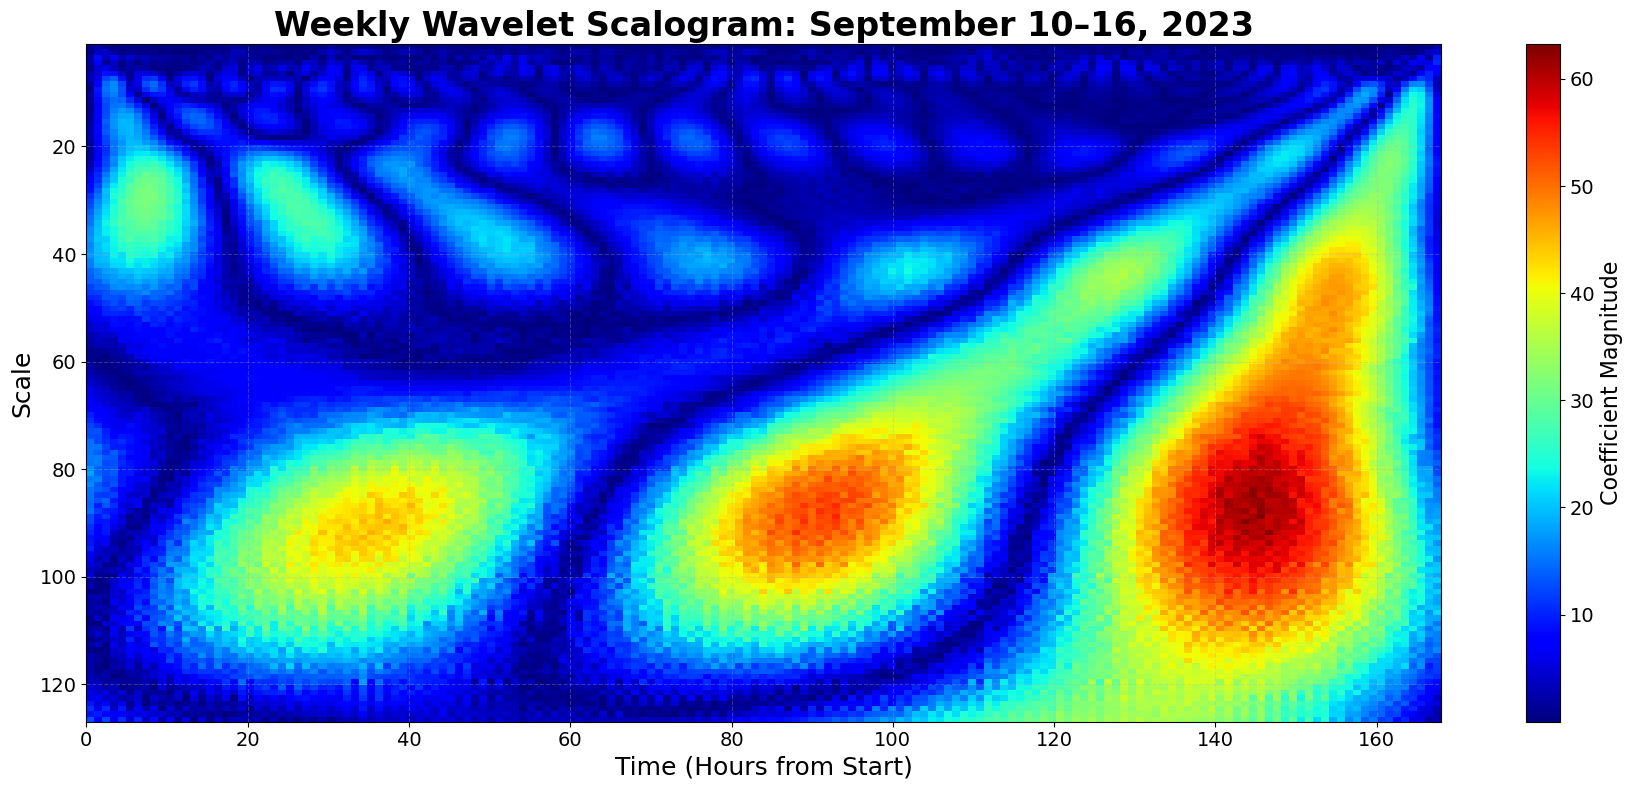

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
import pandas as pd

# Asegurarse de que EFFECTIVE_DATE es datetime
e1_filtered['EFFECTIVE_DATE'] = pd.to_datetime(e1_filtered['EFFECTIVE_DATE'])

# Definir rango de fechas
start_date = pd.to_datetime("2023-09-10")
end_date = pd.to_datetime("2023-09-17")

# Filtrar datos de toda la semana
week_data = e1_filtered[(e1_filtered['EFFECTIVE_DATE'] >= start_date) &
                        (e1_filtered['EFFECTIVE_DATE'] <= end_date)]

if week_data.empty:
    print("No data available for the specified week.")
else:
    # Extraer la señal y convertir fechas a horas relativas
    signal = week_data['ORIG_RAW_VOLUME'].dropna().values
    timestamps = week_data['EFFECTIVE_DATE'].reset_index(drop=True)
    hours = (timestamps - timestamps.min()).dt.total_seconds() / 3600

    # Definir escalas para la transformada Wavelet
    scales = np.arange(1, 128)

    # Aplicar la Transformada Wavelet Continua
    coefficients, frequencies = pywt.cwt(signal, scales, 'morl')

    # Crear la figura del escalograma semanal
    plt.figure(figsize=(18, 8))
    img = plt.imshow(np.abs(coefficients), aspect='auto', cmap='jet',
                     extent=[hours.min(), hours.max(), scales[-1], scales[0]])

    # Título y etiquetas en inglés
    plt.title("Weekly Wavelet Scalogram: September 10–16, 2023", fontsize=24, fontweight="bold")
    plt.xlabel("Time (Hours from Start)", fontsize=18)
    plt.ylabel("Scale", fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # Agregar barra de color
    cbar = plt.colorbar(img)
    cbar.set_label("Coefficient Magnitude", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Escalogramas mensuales

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Obtener los años únicos en el dataframe
years = e1_filtered['EFFECTIVE_DATE'].dt.year.unique()
scales = np.arange(1, 128)  # Definir las escalas para la CWT

# Iterar sobre cada año
for year in years:
    # Filtrar datos para el año actual
    df_year = e1_filtered[e1_filtered['EFFECTIVE_DATE'].dt.year == year]

    # Crear una figura para el año
    fig, axes = plt.subplots(4, 3, figsize=(18, 12))  # 4 filas, 3 columnas
    fig.suptitle(f"Escalogramas Mensuales de Consumo de Gas (Wavelet CWT) - {year}",
                 fontsize=16, fontweight="bold")

    # Iterar sobre cada mes del año
    for i, month in enumerate(range(1, 13)):
        # Filtrar datos para el mes actual
        df_month = df_year[df_year['EFFECTIVE_DATE'].dt.month == month]

        # Seleccionar el eje para la gráfica actual
        ax = axes[i // 3, i % 3]  # Ubicación en la cuadrícula

        if not df_month.empty:
            # Extraer la señal del mes
            signal_month = df_month['ORIG_RAW_VOLUME'].values

            # Aplicar la Transformada Wavelet Continua (CWT) con Morlet
            coefficients, frequencies = pywt.cwt(signal_month, scales, 'morl')

            # Graficar el escalograma
            ax.imshow(np.abs(coefficients), aspect='auto', cmap='jet',
                      extent=[0, len(signal_month), scales[-1], scales[0]])

        # Configurar etiquetas y título
        ax.set_title(f"Mes {month}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Tiempo (Horas en Mes)")
        ax.set_ylabel("Escala")

    # Ajustar el diseño y mostrar la figura
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## Escalogramas Semanales

In [ ]:
import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt
import math

# Escalas para la Transformada Wavelet Continua (CWT)
scales = np.arange(1, 128)

# Obtener los años únicos en el DataFrame
years = e1_filtered['EFFECTIVE_DATE'].dt.year.unique()

# Iterar sobre cada año
for year in years:
    # Filtrar datos para el año actual
    df_year = e1_filtered[e1_filtered['EFFECTIVE_DATE'].dt.year == year].copy()

    # Obtener la lista de semanas únicas en orden correcto
    weeks = sorted(df_year['EFFECTIVE_DATE'].dt.isocalendar().week.unique())

    # Asegurar que la semana 52 se ordena correctamente
    weeks = [w for w in weeks if w != 52] + [52] if 52 in weeks else weeks

    num_weeks = len(weeks)

    # Definir el número de columnas y calcular filas dinámicamente
    num_cols = 6  # Número fijo de columnas para que sea legible
    num_rows = math.ceil(num_weeks / num_cols)  # Número de filas según las semanas

    # Crear la figura con subgráficos
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 2), sharex=True, sharey=True)
    fig.suptitle(f"Escalogramas Semanales de Consumo de Gas (Wavelet CWT) - {year}",
                 fontsize=16, fontweight="bold")

    # Iterar sobre cada semana del año
    for i, week in enumerate(weeks):
        df_week = df_year[df_year['EFFECTIVE_DATE'].dt.isocalendar().week == week]

        # Seleccionar el eje para la gráfica actual
        row, col = divmod(i, num_cols)
        ax = axes[row, col] if num_rows > 1 else axes[col]

        if not df_week.empty:
            # Extraer la señal de la semana
            signal_week = df_week['ORIG_RAW_VOLUME'].values

            # Aplicar la Transformada Wavelet Continua (CWT) con Morlet
            coefficients, frequencies = pywt.cwt(signal_week, scales, 'morl')

            # Graficar el escalograma
            img = ax.imshow(np.abs(coefficients), aspect="auto", cmap="jet",
                            extent=[0, len(signal_week), scales[-1], scales[0]])

        # Configurar etiquetas y título
        ax.set_title(f"Semana {week}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Horas de la Semana")
        ax.set_ylabel("Escala")

    # Ajustar espaciado
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Agregar barra de color
    cbar = fig.colorbar(img, ax=axes.ravel().tolist(), orientation="vertical", fraction=0.02, pad=0.02)
    cbar.set_label("Magnitud")

    # Mostrar la figura
    plt.show()


In [ ]:
print(df_year[df_year['EFFECTIVE_DATE'].dt.isocalendar().week.isin([1, 2])])


## Codigo Original

In [ ]:
import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt
import math

# Cargar los datos desde Excel
e1 = pd.read_excel(r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/datos/EICH101.xlsx")

# Convertir la columna EFFECTIVE_DATE a datetime y establecerla como índice
e1['EFFECTIVE_DATE'] = pd.to_datetime(e1['EFFECTIVE_DATE'])
e1.set_index('EFFECTIVE_DATE', inplace=True)

# Filtrar los datos para el año 2022
df_2022 = e1[e1.index.year == 2022].copy()

# Obtener la lista de semanas únicas en orden correcto
weeks = sorted(df_2022.index.to_series().dt.isocalendar().week.unique())

# Asegurar que la semana 52 se ordena correctamente
weeks = [w for w in weeks if w != 52] + [52] if 52 in weeks else weeks

num_weeks = len(weeks)

# Definir el número de columnas y calcular filas dinámicamente
num_cols = 6  # Número fijo de columnas para que sea legible
num_rows = math.ceil(num_weeks / num_cols)  # Número de filas según las semanas

# Crear la figura con subgráficos
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 2), sharex=True, sharey=True)
fig.suptitle("Escalogramas Semanales de Consumo de Gas (Wavelet CWT - 2022)", fontsize=16, fontweight="bold")

# Escalas para el wavelet
scales = np.arange(1, 128)

# Iterar sobre cada semana y graficar el escalograma
for i, week in enumerate(weeks):
    df_week = df_2022[df_2022.index.to_series().dt.isocalendar().week == week]
    signal_week = df_week["ORIG_RAW_VOLUME"].values

    if len(signal_week) > 0:  # Evitar errores con semanas vacías
        coefficients, frequencies = pywt.cwt(signal_week, scales, "morl")

        # Determinar la posición en la cuadrícula
        row, col = divmod(i, num_cols)
        ax = axes[row, col] if num_rows > 1 else axes[col]

        # Graficar el escalograma
        img = ax.imshow(np.abs(coefficients), aspect="auto", cmap="jet",
                        extent=[0, len(signal_week), scales[-1], scales[0]])
        ax.set_title(f"Semana {week}", fontsize=10, fontweight="bold")
        ax.set_xlabel("Horas de la Semana")
        ax.set_ylabel("Escala")

# Ajustar espaciado
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Agregar barra de color
cbar = fig.colorbar(img, ax=axes.ravel().tolist(), orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Magnitud")

# Mostrar la figura
plt.show()


In [ ]:
# Crear una figura con subgráficos para cada mes del 2022
fig, axes = plt.subplots(4, 3, figsize=(18, 12))  # 4 filas, 3 columnas para los 12 meses
fig.suptitle("Escalogramas Mensuales de Consumo de Gas (Wavelet CWT - 2022)", fontsize=16, fontweight="bold")

# Iterar sobre cada mes del 2022
for i, month in enumerate(range(1, 13)):
    # Filtrar los datos para el mes actual
    df_month = filtered_data_2022[filtered_data_2022['EFFECTIVE_DATE'].dt.month == month]
    signal_month = df_month['ORIG_RAW_VOLUME'].values
    
    # Aplicar la Transformada Wavelet Continua (CWT) con wavelet Morlet
    coefficients, frequencies = pywt.cwt(signal_month, scales, 'morl')
    
    # Seleccionar el eje para la gráfica actual
    ax = axes[i // 3, i % 3]  # Posición en la cuadrícula
    
    # Graficar el escalograma para el mes actual
    ax.imshow(np.abs(coefficients), aspect='auto', cmap='jet',
              extent=[0, len(signal_month), scales[-1], scales[0]])
    
    # Configurar etiquetas y título
    ax.set_title(f"Mes {month}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Tiempo (Horas en Mes)")
    ax.set_ylabel("Escala")

# Ajustar espaciado
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# Filtrar los datos para la semana 1 del año 2019
df_week_1_2019 = e1_filtered[(e1_filtered['EFFECTIVE_DATE'].dt.year == 2019) & 
							 (e1_filtered['EFFECTIVE_DATE'].dt.isocalendar().week == 1)]

# Crear el gráfico de líneas
plt.figure(figsize=(12, 6))
plt.plot(df_week_1_2019['EFFECTIVE_DATE'], df_week_1_2019['ORIG_RAW_VOLUME'], color='blue', alpha=0.7)
plt.title("ORIG_RAW_VOLUME vs Time (Semana 1 del 2019)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("ORIG_RAW_VOLUME")
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrar el gráfico
plt.show()